DATASET DESCRIPTION
Dataset shape: 11000 rows, 19 columns
Column names: ['Age', 'Gender', 'Occupation', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness', 'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event', 'Diet Quality (1-10)', 'Anxiety Level (1-10)']
Data types:
Age                                    int64
Gender                                object
Occupation                            object
Sleep Hours                          float64
Physical Activity (hrs/week)         float64
Caffeine Intake (mg/day)               int64
Alcohol Consumption (drinks/week)      int64
Smoking                               object
Family History of Anxiety             object
Stress Level (1-10)                    int64
Heart Rate (bpm)                       int64
Breat

/tmp/ipykernel_3314/1253693380.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({'Yes': 1, 'No': 0})


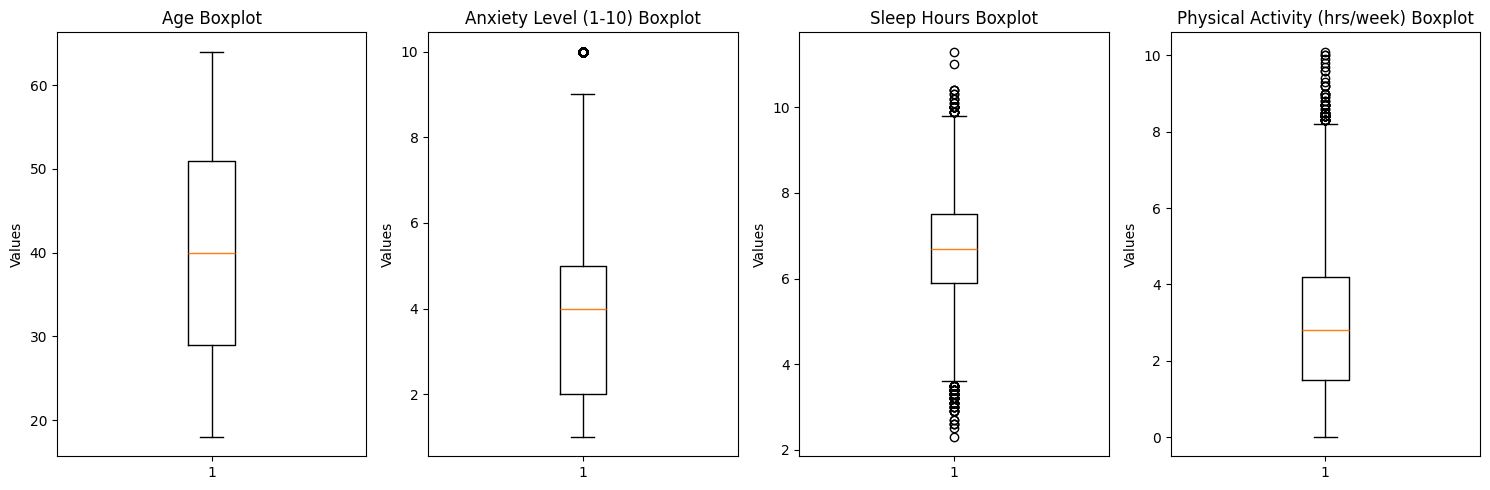

HIGH CORRELATIONS ABS > 0.2
                   Feature 1                    Feature 2  Correlation
         Stress Level (1-10)         Anxiety Level (1-10)     0.721165
   Family History of Anxiety Therapy Sessions (per month)     0.581110
Therapy Sessions (per month)         Anxiety Level (1-10)     0.330756
    Caffeine Intake (mg/day)         Anxiety Level (1-10)     0.282222
                 Sleep Hours         Anxiety Level (1-10)    -0.351404


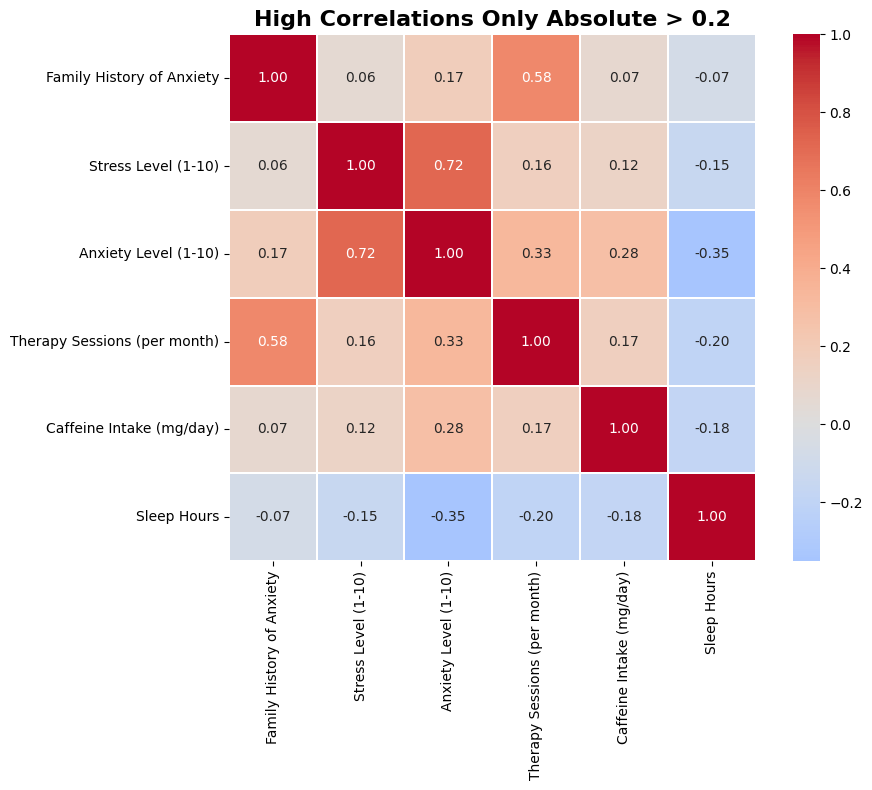

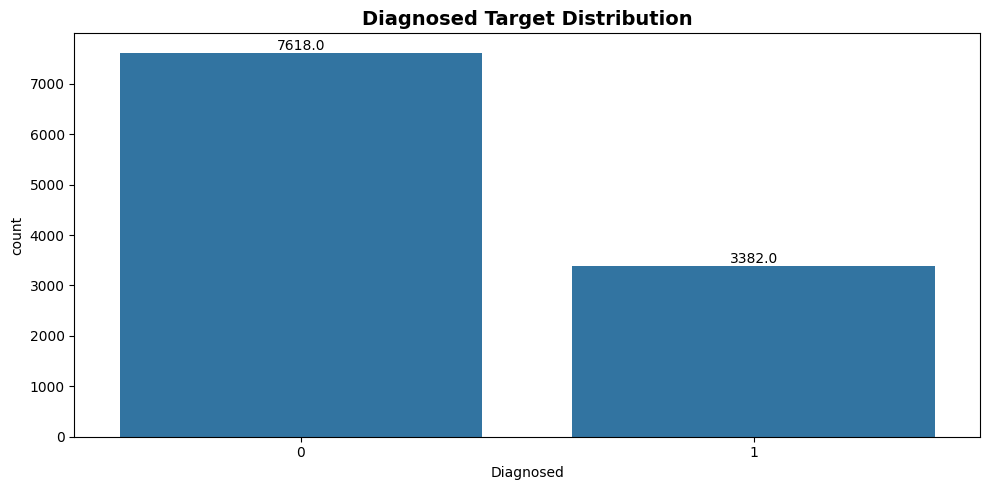

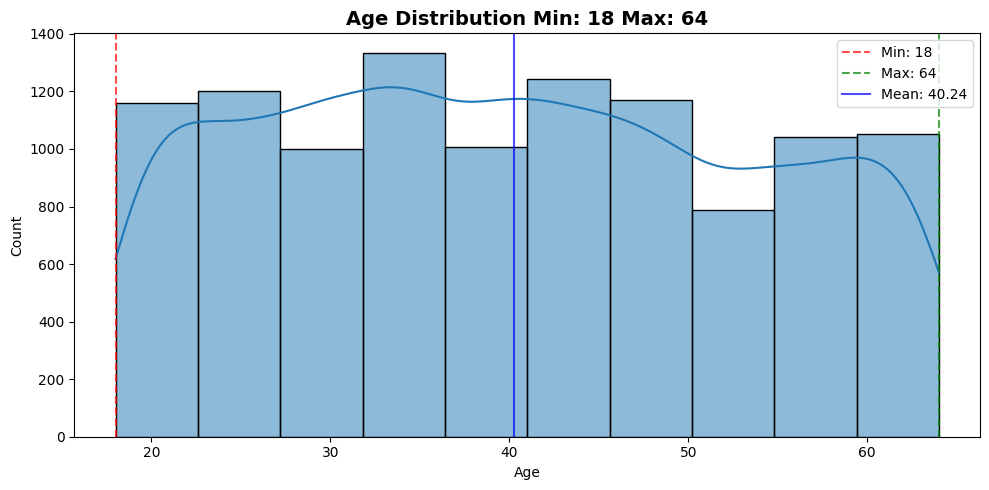

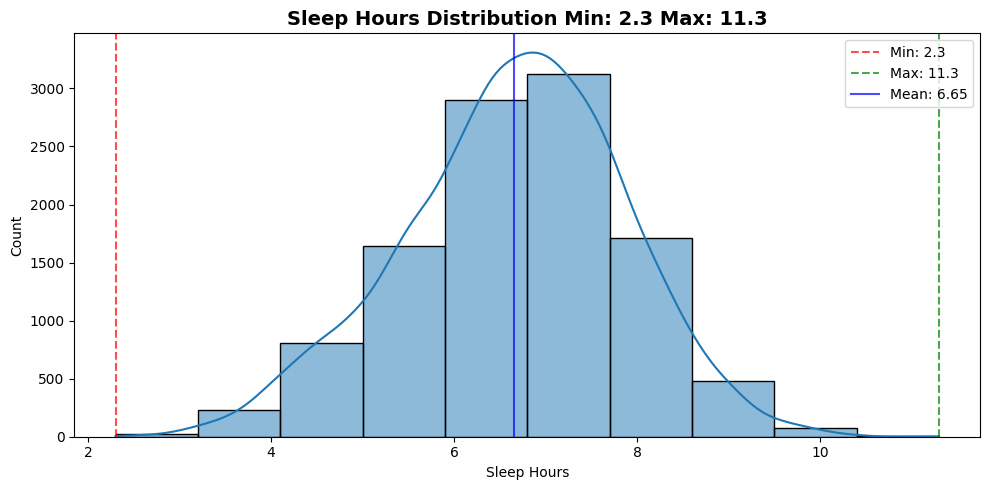

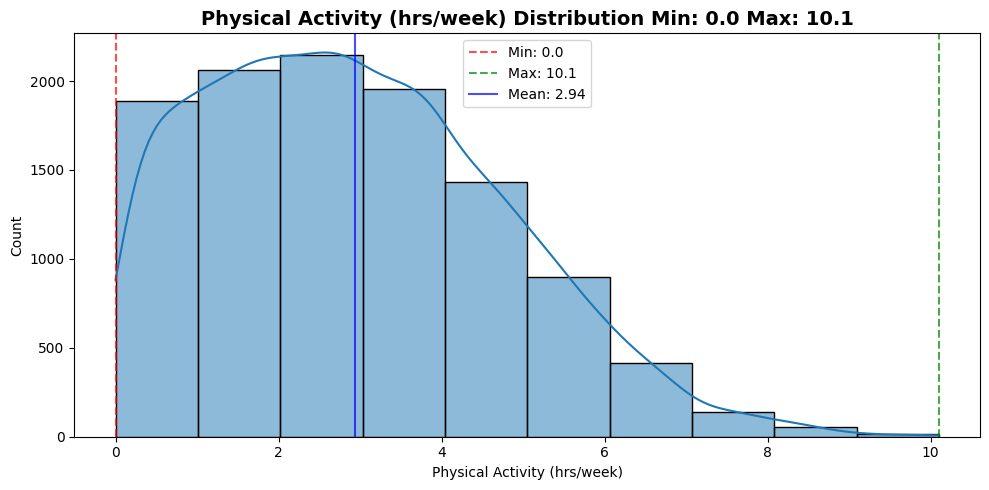

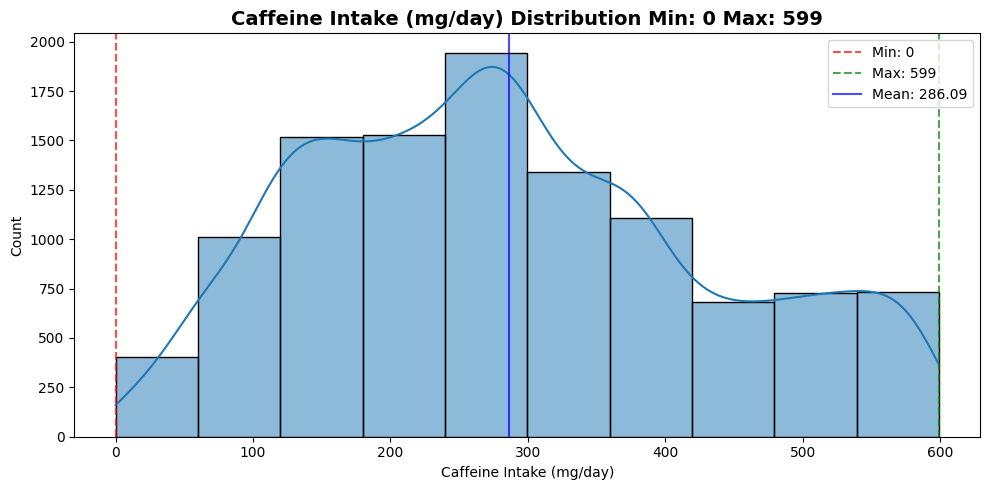

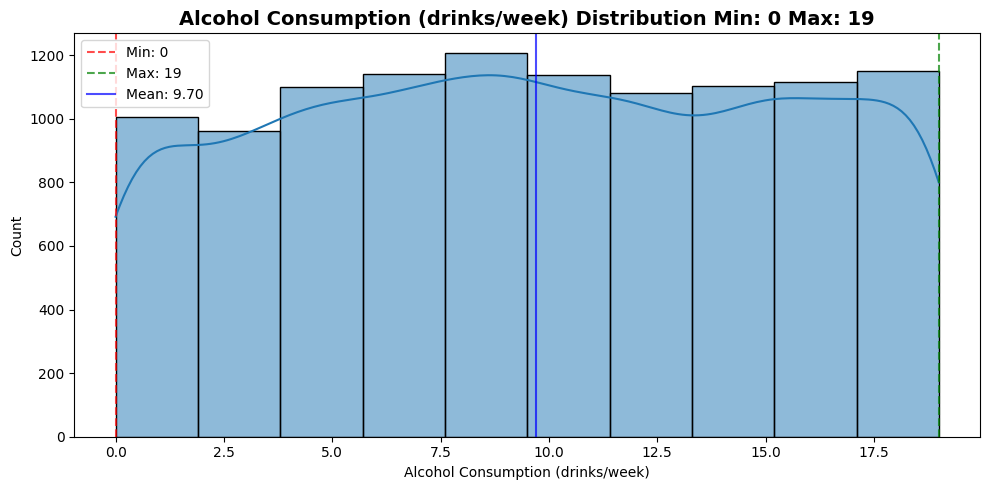

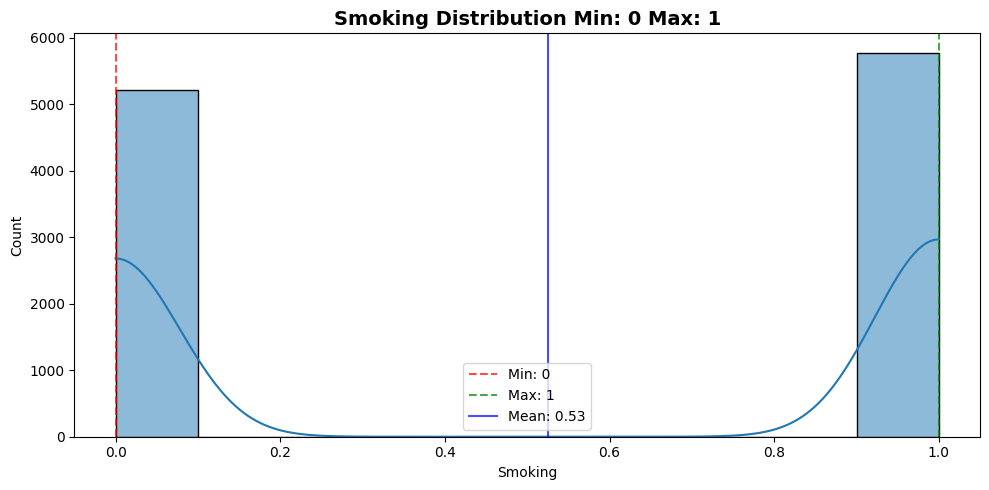

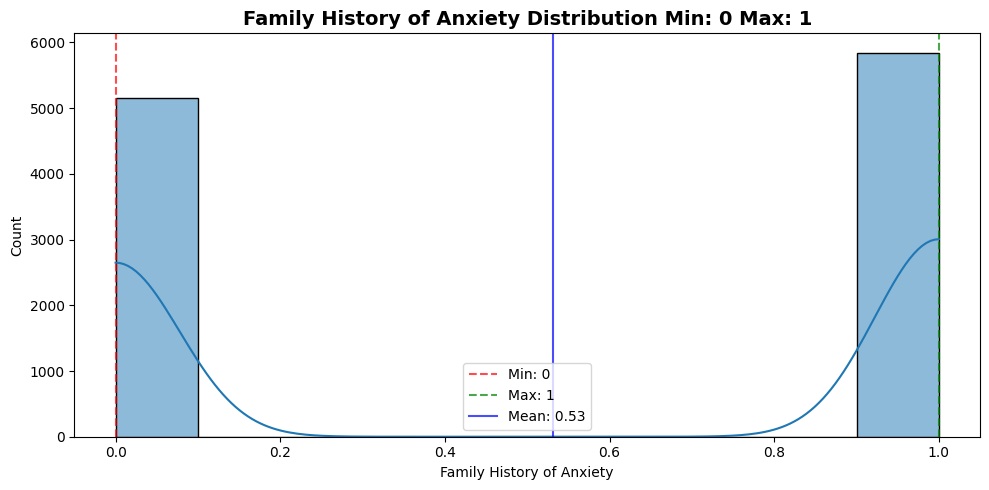

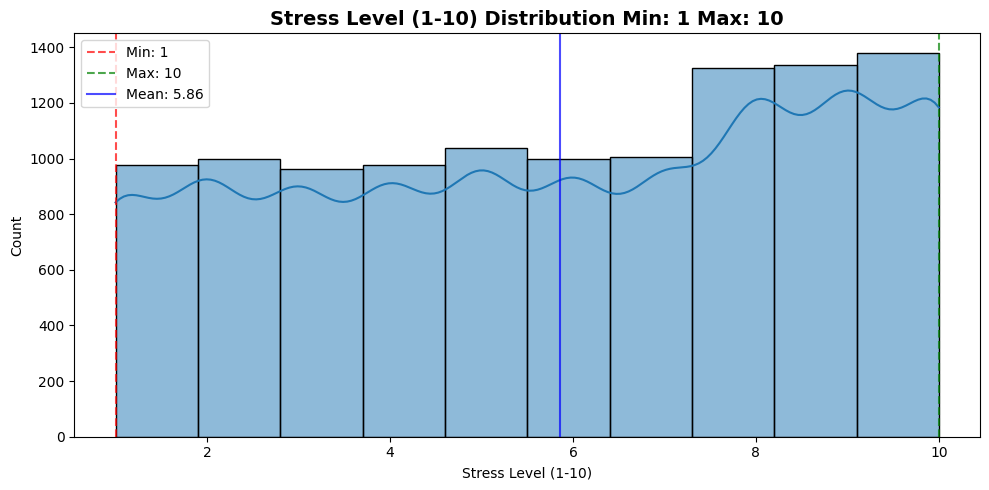

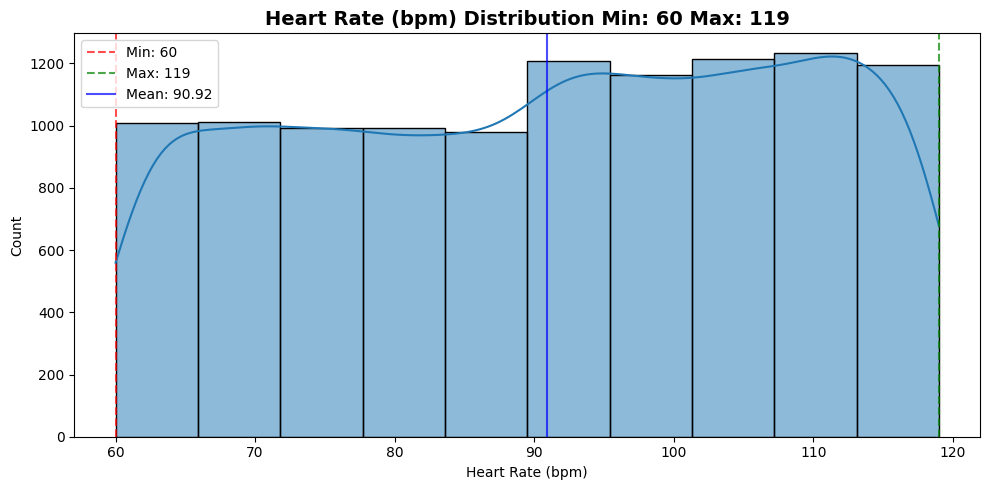

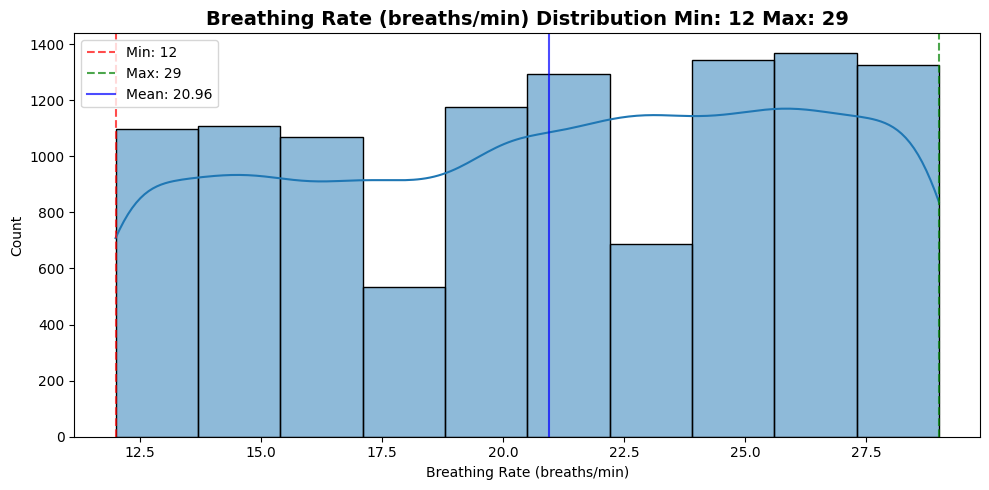

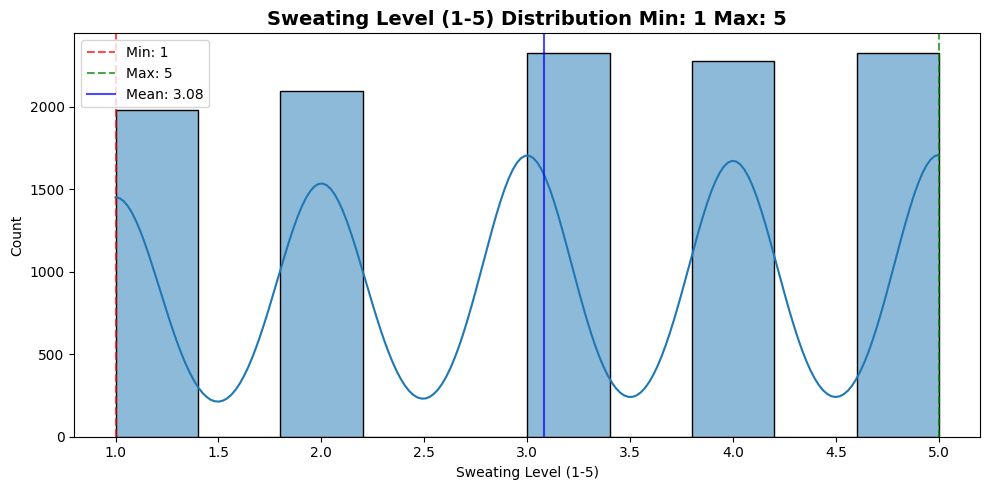

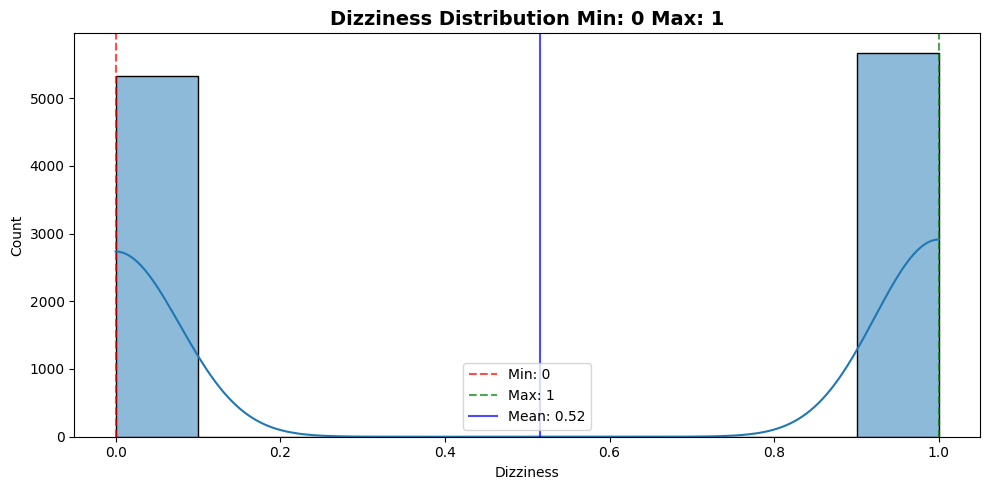

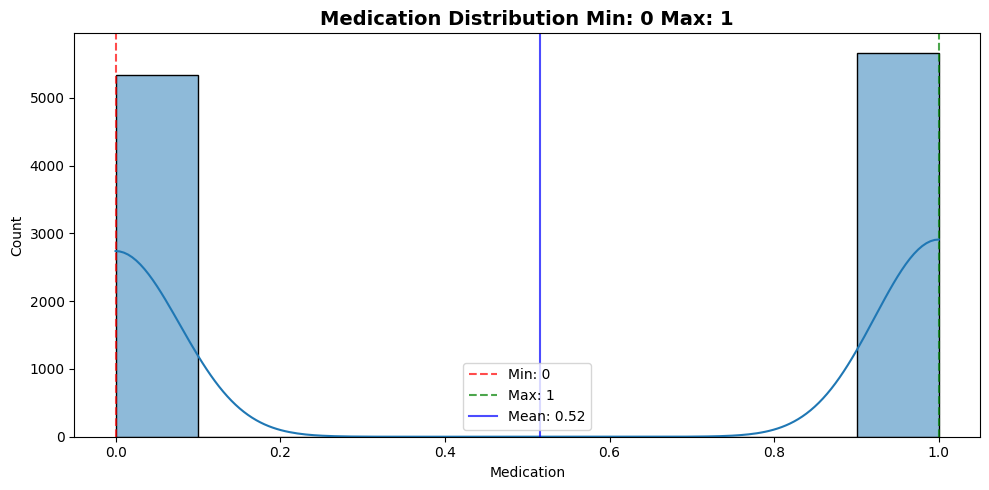

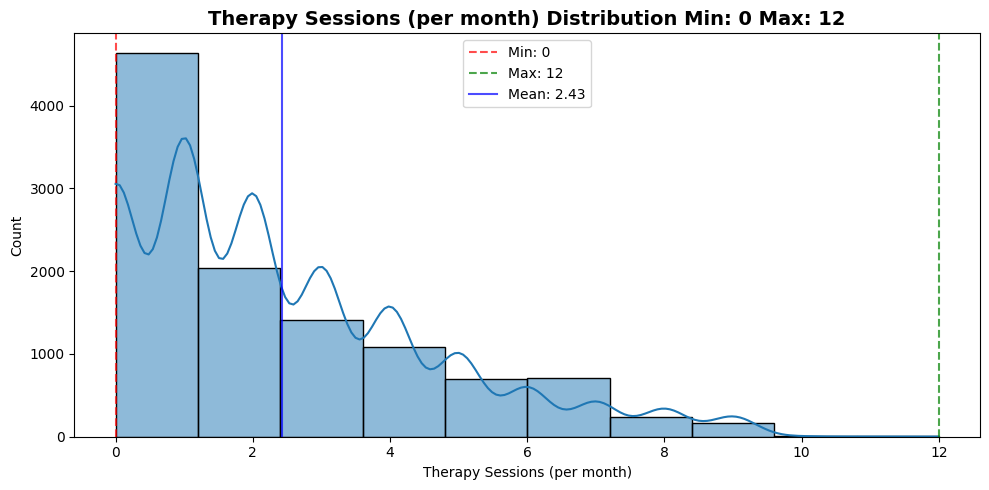

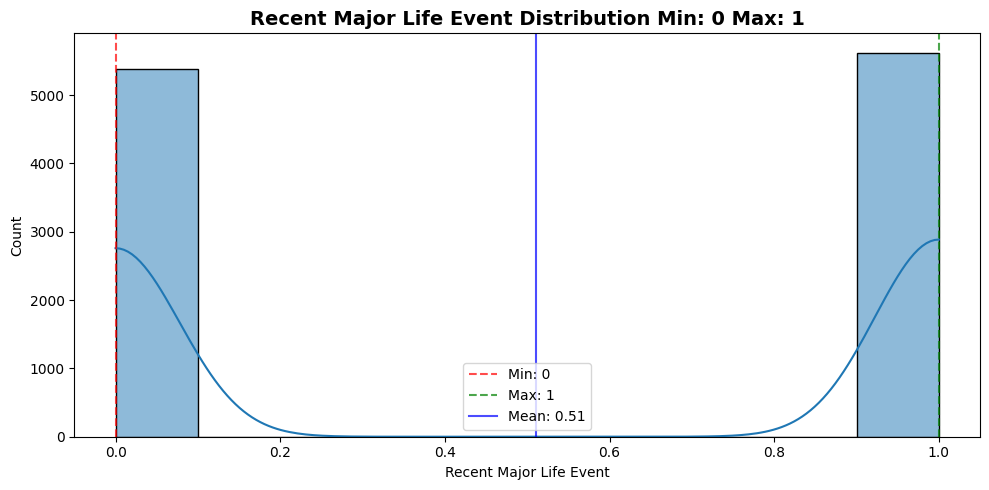

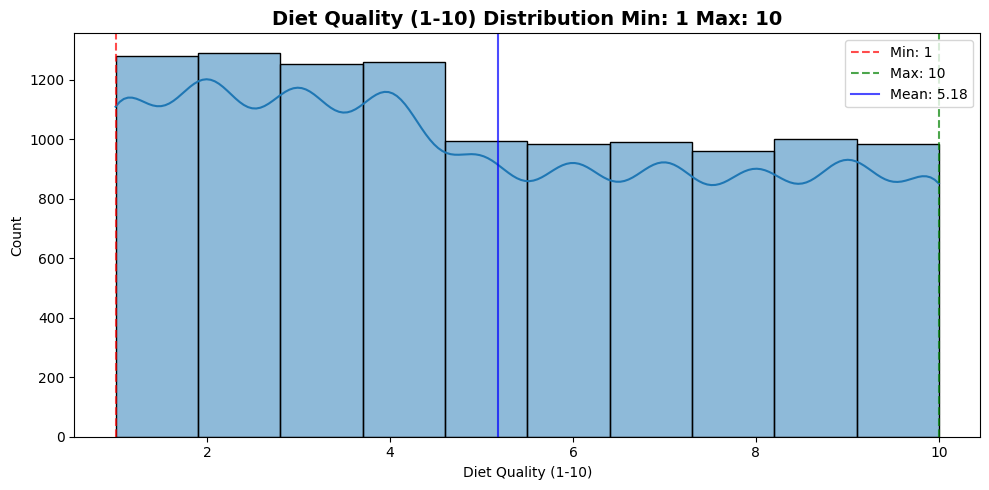

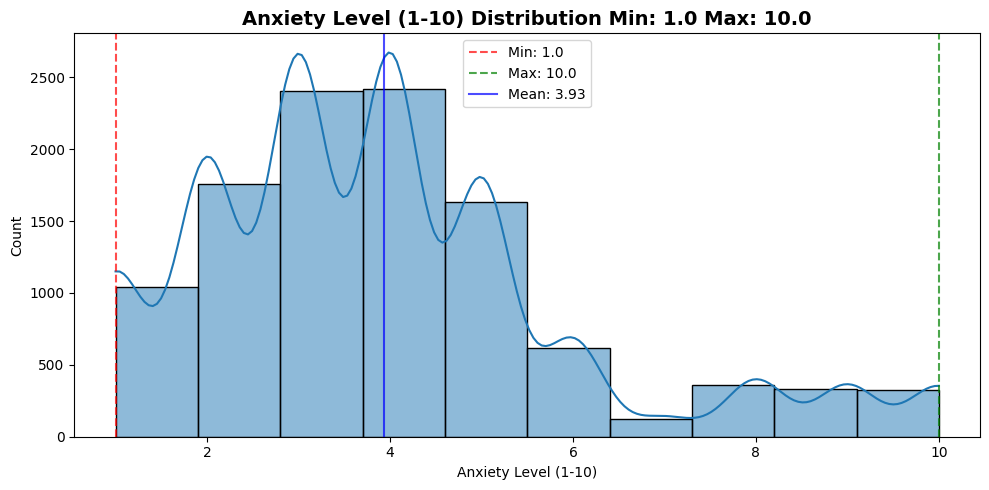

SKEWNESS AND KURTOSIS OF FEATURES
                                   Skewness  Kurtosis
Anxiety Level (1-10)               1.043996  0.950054
Therapy Sessions (per month)       1.035117  0.586923
Physical Activity (hrs/week)       0.507010 -0.215078
Caffeine Intake (mg/day)           0.323941 -0.701446
Sleep Hours                       -0.224472 -0.047568
Diet Quality (1-10)                0.161948 -1.228529
Stress Level (1-10)               -0.160872 -1.255731
Breathing Rate (breaths/min)      -0.141205 -1.171865
Family History of Anxiety         -0.126451 -1.984371
Heart Rate (bpm)                  -0.119204 -1.192624
Smoking                           -0.101599 -1.990039
Age                                0.097336 -1.126341
Sweating Level (1-5)              -0.073929 -1.263226
Dizziness                         -0.062585 -1.996446
Medication                        -0.060399 -1.996715
Recent Major Life Event           -0.044745 -1.998361
Alcohol Consumption (drinks/week) -0.023334 -1.1

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
# data = pd.read_csv("datasets/family_anxiety_14_dataset.csv")
data = pd.read_csv("datasets/enhanced_anxiety_dataset.csv") # testing dataset

# Display basic dataset information
print("DATASET DESCRIPTION")
print(f"Dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Column names: {list(data.columns)}")
print(f"Data types:\n{data.dtypes}")
print(f"Missing values:\n{data.isnull().sum()}")

# Display min and max for each column before conversion
print("MIN AND MAX VALUES FOR EACH COLUMN ORIGINAL")
for col in data.columns:
    if data[col].dtype in ['int64', 'float64']:
        print(f"{col}: Min = {data[col].min()}, Max = {data[col].max()}")
    else:
        print(f"{col} categorical: Unique values = {data[col].nunique()}")
        print(f"  Values: {data[col].unique()[:5]}...")

# Convert Yes/No columns to binary
yes_no_cols = ['Smoking', 'Family History of Anxiety', 'Dizziness', 
               'Medication', 'Recent Major Life Event']
for col in yes_no_cols:
    data[col] = data[col].replace({'Yes': 1, 'No': 0})

# Create target column: Diagnosed if Anxiety Level > 4
data['Diagnosed'] = (data['Anxiety Level (1-10)'] > 4).astype(int)

print("NEW TARGET COLUMN DIAGNOSED")
print(data[['Anxiety Level (1-10)', 'Diagnosed']].head())
print(f"Diagnosed distribution: 0 = {sum(data['Diagnosed']==0)}, 1 = {sum(data['Diagnosed']==1)}")

# Features vs target
features = data.drop(columns=['Diagnosed'])
target = data['Diagnosed']

# Display min and max for numeric features after conversion
numeric_features = features.select_dtypes(include=[np.number])

print("NUMERIC FEATURES MIN AND MAX VALUES")
for col in numeric_features.columns:
    print(f"{col}: Min = {numeric_features[col].min()}, Max = {numeric_features[col].max()}")
    
# Additional statistical summary
print("STATISTICAL SUMMARY OF NUMERIC FEATURES")
print(numeric_features.describe())

# OUTLIER DETECTION FOR CONTINUOUS COLUMNS
print("OUTLIER DETECTION FOR CONTINUOUS COLUMNS")

# Identify continuous columns
continuous_cols = ['Age', 'Anxiety Level (1-10)', 'Sleep Hours', 'Physical Activity (hrs/week)']

print(f"Continuous columns: {continuous_cols}")

# IQR Method for outlier detection
def detect_outliers_iqr(data, columns):
    outlier_summary = {}
    
    for col in columns:
        if col in data.columns:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
            outlier_indices = outliers.index.tolist()
            
            outlier_summary[col] = {
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_count': len(outliers),
                'outlier_percentage': (len(outliers) / len(data)) * 100,
                'outlier_indices': outlier_indices,
                'outlier_values': outliers[col].tolist()
            }
    
    return outlier_summary

# Z-Score Method for outlier detection
def detect_outliers_zscore(data, columns, threshold=3):
    outlier_summary = {}
    
    for col in columns:
        if col in data.columns:
            mean = data[col].mean()
            std = data[col].std()
            z_scores = np.abs((data[col] - mean) / std)
            
            outliers = data[z_scores > threshold]
            outlier_indices = outliers.index.tolist()
            
            outlier_summary[col] = {
                'mean': mean,
                'std': std,
                'threshold': threshold,
                'outlier_count': len(outliers),
                'outlier_percentage': (len(outliers) / len(data)) * 100,
                'outlier_indices': outlier_indices,
                'outlier_values': outliers[col].tolist(),
                'max_zscore': z_scores.max()
            }
    
    return outlier_summary

# Detect outliers using both methods
iqr_outliers = detect_outliers_iqr(data, continuous_cols)
zscore_outliers = detect_outliers_zscore(data, continuous_cols)

# Display IQR method results
print("IQR METHOD OUTLIER RESULTS")
for col, stats in iqr_outliers.items():
    print(f"{col}: {stats['outlier_count']} outliers ({stats['outlier_percentage']:.2f}%)")
    print(f"  Bounds: [{stats['lower_bound']:.2f}, {stats['upper_bound']:.2f}]")
    if stats['outlier_count'] > 0:
        print(f"  Outlier values: {stats['outlier_values']}")

# Display Z-Score method results
print("ZSCORE METHOD OUTLIER RESULTS")
for col, stats in zscore_outliers.items():
    print(f"{col}: {stats['outlier_count']} outliers ({stats['outlier_percentage']:.2f}%)")
    print(f"  Max ZScore: {stats['max_zscore']:.2f}")
    if stats['outlier_count'] > 0:
        print(f"  Outlier values: {stats['outlier_values']}")

# Box plots for visualizing outliers
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(15, 5))
if len(continuous_cols) == 1:
    axes = [axes]

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(f'{col} Boxplot')
    axes[i].set_ylabel('Values')
plt.tight_layout()
plt.show()

# Numeric features correlation heatmap showing only high correlations
print("HIGH CORRELATIONS ABS > 0.2")
corr_matrix = numeric_features.corr(method='spearman')

# Create a mask for correlations with absolute value > 0.2
mask = np.abs(corr_matrix) > 0.2

# Remove diagonal
np.fill_diagonal(mask.values, False)

# Get pairs with high correlation
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if mask.iloc[i, j]:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

# Display high correlation pairs
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No correlations with absolute value > 0.2 found")

# Create heatmap only for high correlations
if high_corr_pairs:
    plt.figure(figsize=(10, 8))
    
    # Get unique features from high correlation pairs
    high_corr_features = list(set([item['Feature 1'] for item in high_corr_pairs] + 
                                  [item['Feature 2'] for item in high_corr_pairs]))
    
    # Filter correlation matrix for these features
    high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
    
    sns.heatmap(high_corr_matrix, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, linewidths=0.2, square=True)
    plt.title("High Correlations Only Absolute > 0.2", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Distribution plots for target and numeric features
targets_and_features = ['Diagnosed'] + list(numeric_features.columns)
for col in targets_and_features:
    plt.figure(figsize=(10, 5))
    if col == 'Diagnosed':
        ax = sns.countplot(x=data[col])
        plt.title("Diagnosed Target Distribution", fontsize=14, fontweight='bold')
        for p in ax.patches:
            ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()), 
                       ha='center', va='bottom')
    else:
        ax = sns.histplot(data[col], bins=10, kde=True)
        plt.title(f'{col} Distribution Min: {data[col].min()} Max: {data[col].max()}', 
                 fontsize=14, fontweight='bold')
        plt.axvline(data[col].min(), color='red', linestyle='--', alpha=0.7, label=f'Min: {data[col].min()}')
        plt.axvline(data[col].max(), color='green', linestyle='--', alpha=0.7, label=f'Max: {data[col].max()}')
        plt.axvline(data[col].mean(), color='blue', linestyle='-', alpha=0.7, label=f'Mean: {data[col].mean():.2f}')
        plt.legend()
    plt.tight_layout()
    plt.show()

# Skewness and kurtosis for numeric features
skew_kurt = pd.DataFrame({
    'Skewness': numeric_features.skew(),
    'Kurtosis': numeric_features.kurtosis()
}).sort_values(by='Skewness', key=abs, ascending=False)

print("SKEWNESS AND KURTOSIS OF FEATURES")
print(skew_kurt)

# Categorical features summary
categorical_features = features.select_dtypes(include=['object', 'category']).columns

print("CATEGORICAL FEATURES SUMMARY")
for col in categorical_features:
    print(f"Categorical Feature: {col}")
    print(f"Number of unique values: {data[col].nunique()}")
    print("Value counts top 10:")
    print(data[col].value_counts().head(10))

# Save cleaned dataset
# data.to_csv("training_dataset.csv", index=False)
data.to_csv("testing_dataset.csv", index=False)

print(f"Final dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")